Creating Spearman heatmap for states for RQ2

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


In [2]:
# general protective behaviour train set

state_train_general_behav = pd.read_csv("state_train_general_behav.csv")

states = sorted(state_train_general_behav["state"].unique()) # to get 8 states



# load full feature importance csv of each state
importance_state = {}

for state in states:

    state_importance_dataset = pd.read_csv(f"RQ2_general_behav_{state}_RF_FeatureImportance_rolling.csv")

    # feature names are the index, importance values is  a series.
    importance_state[state] = state_importance_dataset.set_index("Feature")["Importance"]





# combine into one dataframe
# rows = features   columns = states

importance_matrix = pd.DataFrame(importance_state)


print(importance_matrix.shape)  # should be 8 columns/ same feature set as rows
print(importance_matrix.head())

print(f"\n any NAs: ", importance_matrix.isna().sum())


(53, 8)
                                          Australian Capital Territory  \
Feature                                                                  
7days_rolling_cases                                           0.119942   
7days_rolling_deaths                                          0.020590   
Can't control worrying_Nearly every day                       0.001999   
Can't control worrying_Not at all                             0.005273   
Can't control worrying_Prefer not to say                      0.000000   

                                          New South Wales  Northern Territory  \
Feature                                                                         
7days_rolling_cases                              0.063892            0.036188   
7days_rolling_deaths                             0.046460            0.001060   
Can't control worrying_Nearly every day          0.001061            0.002615   
Can't control worrying_Not at all                0.001257           

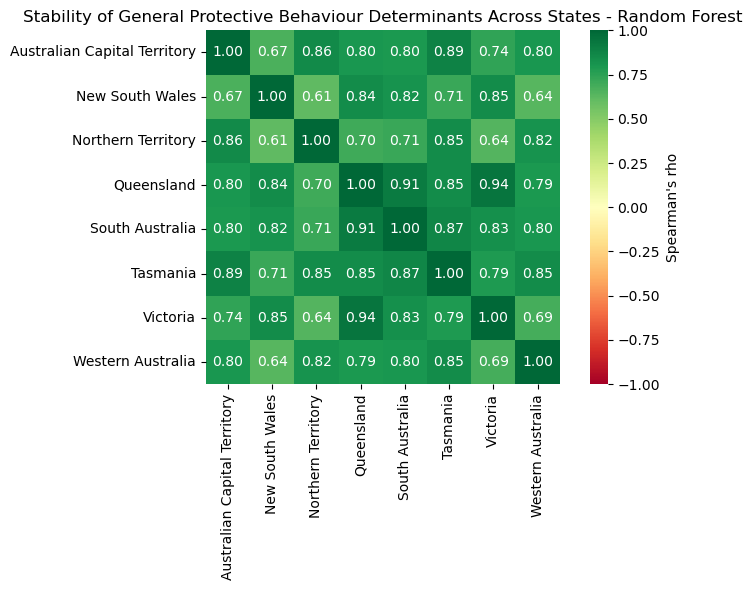

In [3]:
# Spearman correlation between states
rho_matrix = pd.DataFrame(index=states, columns=states, dtype=float)
pval_matrix = pd.DataFrame(index=states, columns=states, dtype=float)

for state1 in states:
    for state2 in states:
        rho, pval = spearmanr(importance_matrix[state1], importance_matrix[state2])
        # rho = spearmanr(importance_matrix[state1], importance_matrix[state2])
        rho_matrix.loc[state1, state2] = rho
        pval_matrix.loc[state1, state2] = pval





# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(rho_matrix.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Spearman's rho"})
plt.title("Stability of General Protective Behaviour Determinants Across States - Random Forest")
plt.tight_layout()
plt.savefig("RQ2_general_behav_RF_SpearmanHeatmap_rolling.png", dpi=300, bbox_inches="tight")
plt.show()

rho_matrix.to_csv("RQ2_general_behav_RF_SpearmanRho_rolling.csv")
# pval_matrix.to_csv("RQ2_facemask_RF_SpearmanPval.csv")